<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI/blob/main/ProjectsinMLAIhw5_taskGraduate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNNs, AEs, GANs, Attention Mechanism

## Graduate Task - Medical Image Segmentation

In [30]:
import os
os.environ["DISABLE_WIDGETS"] = "1"

In [31]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset("Angelou0516/CVC-ClinicDB")

# Access splits
train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

# Access a sample
sample = train_data[0]




Resolving data files:   0%|          | 0/981 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

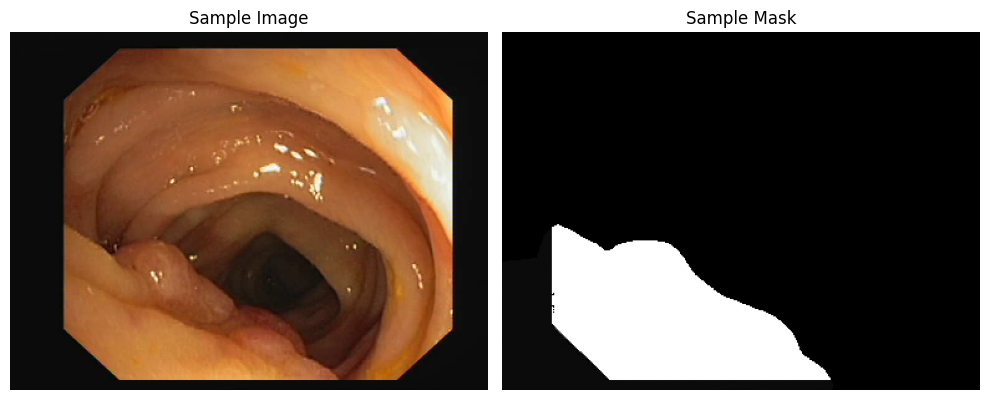

In [32]:
import matplotlib.pyplot as plt

image = sample['image']
mask = sample['mask']

plt.figure(figsize=(10, 5))

# Display the image
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Sample Image')
plt.axis('off')

# Display the mask
plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Sample Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

### Research on Existing Models

Key Findings:

* U-Net remains one of the most preferred architectures for segmentation. Its encoder-decoder design, combined with skip connections, make it uniquely capable of recovering fine spatial details from the colonoscopy images.
* There are also other architectures like SegNet, FCN, and R-CNNs that have been used in studies.
* A major finding is the gap between academic accuracy and clinical applicability. While many deep learning models achieve high accuracy, they are often too computationally heavy to run in real-time during a live procedure.
* Despite the existence of datasets like CVC-ClinicDB, there is always the lack of massive, heavily annotated datasets, which limits the generalization of these models.


Evaluation Metrics:

* The most common combination of metrics used is precision, recall, and F1 scores.
* The standard evaluation metric for segmentation tasks is Intersection-Over-Union (IoU) or the Jaccard Index and the Dice Score.

Citations:
* ElKarazle, K., Raman, V., Then, P., & Chua, C. (2023). Detection of colorectal polyps from colonoscopy using machine learning: A survey on modern techniques. Sensors, 23(3), 1225. https://doi.org/10.3390/s23031225
* Yang, K., Chang, S., Tian, Z., Gao, C., Du, Y., Zhang, X., Liu, K., Meng, J., & Xue, L. (2022). Automatic polyp detection and segmentation using shuffle efficient channel attention network. Alexandria Engineering Journal, 61(1), 917–926. https://doi.org/10.1016/j.aej.2021.04.072
* Tudela, Y., Majó, M., de la Fuente, N., Galdran, A., Krenzer, A., Puppe, F., Yamlahi, A., Tran, T. N., Matuszewski, B. J., Fitzgerald, K., Bian, C., Pan, J., Liu, S., Fernández-Esparrach, G., Histace, A., & Bernal, J. (2024). A complete benchmark for polyp detection, segmentation and classification in colonoscopy images. Frontiers in Oncology, 14, 1417862. https://doi.org/10.3389/fonc.2024.1417862

In [33]:
import torch.nn as nn
import torch

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder (Downsampling)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # Bottleneck
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(128, 64)

        # Final Output Layer
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder Pathway
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder Pathway with Skip Connections
        x = self.up1(x5)
        x = torch.cat([x4, x], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        return logits

Train and Evaluate

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class HFPolypDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # Fetch the row
        sample = self.hf_dataset[idx]

        image = sample['image']
        mask = sample['mask']

        # Ensure the color channels are correct for U-Net
        image = image.convert("RGB")
        mask = mask.convert("L") # Grayscale

        # Apply the resizes and convert to PyTorch Tensors
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

# Resize to 128x128 for computational efficiency
IMG_SIZE = 128
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [35]:
# Wrap the Hugging Face splits
train_dataset = HFPolypDataset(train_data, transform=transform)
val_dataset = HFPolypDataset(val_data, transform=transform)
test_dataset = HFPolypDataset(test_data, transform=transform)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Loaded {len(train_loader.dataset)} training images!")

Loaded 490 training images!


In [36]:
import torch.optim as optim

def calculate_all_metrics(pred, target, smooth=1e-6):
    # Push raw logits to probabilities and threshold at 0.5
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    # Calculate True Positives, False Positives, and False Negatives per image in the batch
    TP = (pred * target).sum(dim=(2, 3))
    FP = (pred * (1 - target)).sum(dim=(2, 3))
    FN = ((1 - pred) * target).sum(dim=(2, 3))

    # Dice Score (F1 Score)
    dice = (2. * TP + smooth) / (2. * TP + FP + FN + smooth)

    # Intersection over Union (IoU)
    iou = (TP + smooth) / (TP + FP + FN + smooth)

    # Precision
    precision = (TP + smooth) / (TP + FP + smooth)

    # Recall
    recall = (TP + smooth) / (TP + FN + smooth)

    # Return the average across the batch
    return dice.mean().item(), iou.mean().item(), precision.mean().item(), recall.mean().item()

# Setup device and model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(n_channels=3, n_classes=1).to(device)

# Binary Cross Entropy with Logits
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 30

print(f"Starting training on device: {device}")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_dice, epoch_iou, epoch_prec, epoch_recall = 0, 0, 0, 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        b_dice, b_iou, b_prec, b_recall = calculate_all_metrics(outputs, masks)
        epoch_dice += b_dice
        epoch_iou += b_iou
        epoch_prec += b_prec
        epoch_recall += b_recall

    # Calculate averages
    avg_loss = epoch_loss / len(train_loader)
    avg_dice = epoch_dice / len(train_loader)
    avg_iou = epoch_iou / len(train_loader)
    avg_prec = epoch_prec / len(train_loader)
    avg_recall = epoch_recall / len(train_loader)

    print(f'Epoch: {epoch+1:02} | Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f} | Recall: {avg_recall:.4f}')

Starting training on device: cuda
Epoch: 01 | Loss: 0.5076 | Dice: 0.3599 | IoU: 0.2535 | Recall: 0.5539
Epoch: 02 | Loss: 0.3752 | Dice: 0.4655 | IoU: 0.3594 | Recall: 0.4942
Epoch: 03 | Loss: 0.3301 | Dice: 0.5314 | IoU: 0.4243 | Recall: 0.5515
Epoch: 04 | Loss: 0.3019 | Dice: 0.5824 | IoU: 0.4743 | Recall: 0.5928
Epoch: 05 | Loss: 0.2852 | Dice: 0.6047 | IoU: 0.4928 | Recall: 0.6315
Epoch: 06 | Loss: 0.2610 | Dice: 0.6707 | IoU: 0.5610 | Recall: 0.6878
Epoch: 07 | Loss: 0.2438 | Dice: 0.7132 | IoU: 0.6031 | Recall: 0.7478
Epoch: 08 | Loss: 0.2245 | Dice: 0.7558 | IoU: 0.6541 | Recall: 0.7855
Epoch: 09 | Loss: 0.2158 | Dice: 0.7706 | IoU: 0.6675 | Recall: 0.7951
Epoch: 10 | Loss: 0.2045 | Dice: 0.7815 | IoU: 0.6846 | Recall: 0.8140
Epoch: 11 | Loss: 0.1994 | Dice: 0.7608 | IoU: 0.6620 | Recall: 0.7837
Epoch: 12 | Loss: 0.1827 | Dice: 0.8103 | IoU: 0.7166 | Recall: 0.8471
Epoch: 13 | Loss: 0.1697 | Dice: 0.8323 | IoU: 0.7460 | Recall: 0.8487
Epoch: 14 | Loss: 0.1577 | Dice: 0.8670 | I

Evaluation on Test data

In [37]:
model.eval()

test_loss = 0
test_dice, test_iou, test_prec, test_recall = 0, 0, 0, 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        test_loss += loss.item()

        # Calculate metrics
        b_dice, b_iou, b_prec, b_recall = calculate_all_metrics(outputs, masks)

        test_dice += b_dice
        test_iou += b_iou
        test_prec += b_prec
        test_recall += b_recall

# Calculate final averages
avg_test_loss = test_loss / len(test_loader)
avg_test_dice = test_dice / len(test_loader)
avg_test_iou = test_iou / len(test_loader)
avg_test_prec = test_prec / len(test_loader)
avg_test_recall = test_recall / len(test_loader)

print("=== FINAL TEST SET RESULTS ===")
print(f'Test Loss:   {avg_test_loss:.4f}')
print(f'Test Dice:   {avg_test_dice:.4f}')
print(f'Test IoU:    {avg_test_iou:.4f}')
print(f'Test Recall: {avg_test_recall:.4f}')
print(f'Test Precision:{avg_test_prec:.4f}')

=== FINAL TEST SET RESULTS ===
Test Loss:   0.0900
Test Dice:   0.8745
Test IoU:    0.8056
Test Recall: 0.8685
Test Precision:0.9061


For this task, I implemented a baseline U-Net architecture and evaluated it using the Dice Coefficient, as recommended by the literature (ElKarazle et al., 2023). My baseline model achieved a Dice score of 0.8745 on the CVC-ClinicDB dataset. When comparing my results to modern architectures, Yang et al. (2022) demonstrated that integrating channel attention mechanisms (SEANet) yields significantly higher performance, achieving Dice scores in the ~0.90 range by better distinguishing polyp boundaries from the surrounding mucosa. Furthermore, as noted by Tudela et al. (2024), while my baseline model proves the viability of encoder-decoder networks for segmentation, future iterations must account for video-frame data leakage to ensure the model generalizes to entirely unseen patients.